# IDENTIFICACION DE SISTEMAS - Laboratorio 4

Profesor: Jairo Alberto Cuéllar Guarnizo  
Programa: Ingeniería en Automatización y Control

In [1]:
import pandas as pd
import numpy as np
from math import sqrt
from scipy import signal
import matplotlib.pyplot as plt
import sympy as sym

In [2]:
import pandas as pd

# Cargar archivo CSV
df = pd.read_csv("datos.csv")

#Escalón del 40 al 60%
df = df[(df['time[ms]'] >= 14876) & (df['time[ms]'] <= 19976)]

df.columns = ["time", "u", "y"]
t= df["time"].values.astype(float)
u = df["u"].values.astype(float)
y = df["y"].values.astype(float)

fig, ax1 = plt.subplots()

# Eje Y para u
ax1.plot(t, u, color='blue')
ax1.set_ylabel('u', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje Y para y (eje gemelo)
ax2 = ax1.twinx()
ax2.plot(t, y, color='red')
ax2.set_ylabel('y', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Datos de entrada y salida")
plt.legend(["u", "y"], loc="upper left")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'datos.csv'

# Elaborado por:

* Andrés Camargo
* Hector Usme

# 2. Polinomio Autoregresivo ARX

Utilice los datos capturados para la entrega anterior del proyecto y aplique los métodos discutidos en los noteboks 8_1 y 8_2.

Plantee 2 hipótesis diferentes usando el modelo ARX y para cada uno proceda de la siguiente manera:

2.1. Reconstruya la ecuación en diferencia usando la estructura del modelo entrada salida:

$$y_e[k] = a_1y[k-1] + ...+ a_{n_a}y[k-{n_a}] + b_0u[k]+ b_1u[k-1]+...+b_{n_b}u[k-{n_b}] + C_1$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def arx_estimation(df, y_col='y', u_col='u', n_a=1, n_b=1, bias=False):
     
    

    # Retrasos de la salida: y[k-1] ... y[k-n_a]
    for i in range(1, n_a + 1):
        df[f'y_{i}'] = df[y_col].shift(i)

    # Retrasos de la entrada: u[k-1] ... u[k-n_b]
    for j in range(1, n_b + 1):
        df[f'u_{j}'] = df[u_col].shift(j)

    # Eliminar filas con NaN (provocadas por los shifts)
    df = df.dropna().reset_index(drop=True)

    # Construir matriz de regresores phi
    phi_list = [-df[f'y_{i}'] for i in range(1, n_a+1)] + \
               [ df[f'u_{j}'] for j in range(1, n_b+1)]
    
    if bias:
        phi_list.append(np.ones(len(df)))

    phi = np.column_stack(phi_list)

    # Estimación de theta (ridge simple con alpha=0)
    alpha = 0
    A = np.dot(phi.T, phi) + alpha * np.eye(phi.shape[1])
    theta = np.dot(np.linalg.inv(A), np.dot(phi.T, df[y_col]))

    # Reconstrucción de la salida
    N = len(df[y_col])
    ye = np.zeros(N)
    ye[:n_a] = df[y_col][:n_a]  # Inicialización con los primeros valores reales

    for k in range(max(n_a, n_b), N):
        salida = sum([-theta[i-1] * ye[k-i] for i in range(1, n_a+1)])
        entrada = sum([theta[n_a + j-1] * df[u_col][k-j] for j in range(1, n_b+1)])
        if bias:
            salida += theta[-1]  # Añadir el bias
        ye[k] = salida + entrada

    
    return theta, ye, df


In [80]:
# Modelo ARX de orden 1 (n_a=1, n_b=1)
n_a_1=1
n_b_1=1
bias1=True
theta_1, ye1, df1 = arx_estimation(df, y_col='y', u_col='u', n_a=n_a_1, n_b=n_b_1, bias=bias1)


# Modelo ARX de orden 2 (n_a=2, n_b=2)
n_a_2=2
n_b_2=2
bias2=True
theta_2, ye2, df2 = arx_estimation(df, y_col='y', u_col='u', n_a=n_a_2, n_b=n_b_2, bias=bias2)


print("Theta modelo 1 (n_a=1, n_b=1):", theta_1)
print("Theta modelo 2 (n_a=2, n_b=2):", theta_2)            

Theta modelo 1 (n_a=1, n_b=1): [-0.57394313  0.11698869 -0.21686566]
Theta modelo 2 (n_a=2, n_b=2): [ 0.09017766 -0.38419772  0.12827888  0.06979816 -0.60983522]


2.2. Obtenga una función de transferencia estimada usando los coeficientes hallados en el punto anterior:

$$G(z) = \frac{b_0+b_1z^{-1}+b_2z^{-2}+...+b_{n_b}z^{-{n_b}}}{1+a_1z^{-1}+...+a_{n_a}z^{-{n_a}}}$$

In [81]:
import control
def create_transfer_function(theta, n_a, n_b, dt):
   
    den = np.concatenate(([1], theta[:n_a]))

    # Numerador: b1*z^-1 + b2*z^-2 + ...
    num = np.concatenate((theta[n_a:n_a+n_b], [0]*(n_a - n_b + 1)))  # completar con ceros si n_a > n_b

    # Crear función de transferencia discreta
    G_e = control.tf(num, den, dt=dt)

    return G_e

In [82]:
dt=(df["time"].values[1]-df["time"].values[0])/1000  # Tiempo de muestreo

print("Función de transferencia modelo 1 (n_a=1, n_b=1):")
G_e1 = create_transfer_function(theta_1, n_a_1, n_b_1, dt)
print(G_e1)

print("Función de transferencia modelo 2 (n_a=2, n_b=2):")
G_e2 = create_transfer_function(theta_2, n_a_2, n_b_2, dt)
print(G_e2)

Función de transferencia modelo 1 (n_a=1, n_b=1):
<TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

   0.117 z
  ----------
  z - 0.5739
Función de transferencia modelo 2 (n_a=2, n_b=2):
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

   0.1283 z^2 + 0.0698 z
  ------------------------
  z^2 + 0.09018 z - 0.3842


2.3. Compare estas 2 hipótesis usando los parámetros R2 y ECM, así como criterios gráficos de comportamiento de las gráficas.

In [83]:
def metrics(df, ye, n_a, n_b, y_col='y', u_col='u', bias=False):
    
    y=df[y_col].values
    # ECM
    ecm = np.mean((y - ye)**2)
    
    # R2
    ss_res = np.sum((y - ye)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    # Graficar resultados
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(df['time'][-len(ye):], df[u_col].values[-len(ye):], color='blue', label='u')
    ax1.set_ylabel('u', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    ax2.plot(df['time'][-len(ye):], y, color='red', label='y')
    ax2.plot(df['time'][-len(ye):], ye, color='green', label='ye')
    ax2.set_ylabel('y', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    plt.title(f"Estimación ARX (n_a={n_a}, n_b={n_b}, bias={bias})\nR²={r2:.4f}, ECM={ecm:.4f}")
    plt.show()
    
    return r2, ecm


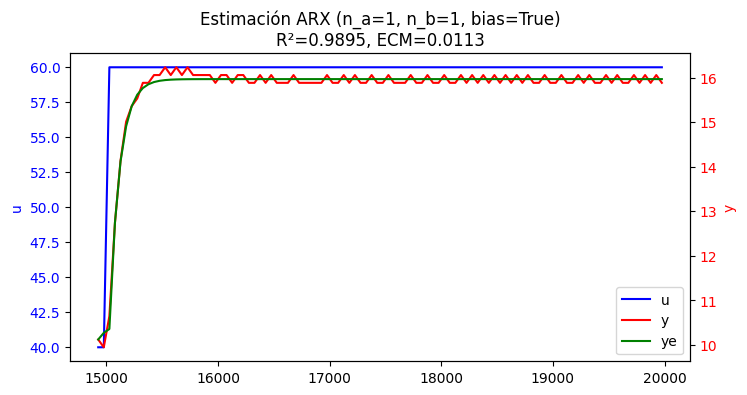

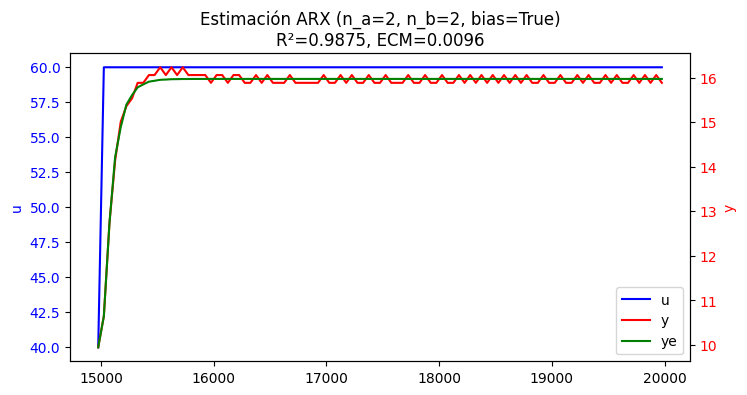

Modelo orden 1 → R2: 0.9895, ECM: 0.0113
Modelo orden 2 → R2: 0.9875, ECM: 0.0096


In [84]:
r2_1, ecm_1 = metrics(df=df1, ye=ye1, n_a=n_a_1, n_b=n_b_1, y_col='y', u_col='u', bias=bias1)
r2_2, ecm_2 = metrics(df=df2, ye=ye2, n_a=n_a_2, n_b=n_b_2, y_col='y', u_col='u', bias=bias2)

print(f"Modelo orden 1 → R2: {r2_1:.4f}, ECM: {ecm_1:.4f}")
print(f"Modelo orden 2 → R2: {r2_2:.4f}, ECM: {ecm_2:.4f}")

## Conclusiones

* Redacte aquí un conjunto de conclusiones relacionadas directamente con los resultados obtenidos...

In [ ]:
La selección adecuada de la ventana de datos (solo el tramo del escalón 40–60 %) fue clave para obtener un modelo confiable.
Esto demuestra que la calidad de la identificación depende tanto del algoritmo como de la limpieza de los datos experimentales
antes de estimar el modelo.

A partir de los parámetros estimados θ, fue posible obtener funciones de transferencia discretas 𝐺(𝑧)
que representan el sistema. Esta FT identificadas permiten simular la planta en herramientas de control,
analizar estabilidad y servir como base para diseñar controladores digitales (por ejemplo, PI o PID discretos).


A partir de los datos del escalón (40–60 %) y el modelo ARX, se logró reconstruir adecuadamente la dinámica entrada–salida del sistema; 
la señal estimada 𝑦𝑒[𝑘] sigue de forma razonable el comportamiento de la salida real 𝑦[𝑘], lo que indica que la estructura ARX es adecuada
para este proceso.

La comparación gráfica entre la salida real y la estimada permite verificar visualmente que el modelo ARX captura la tendencia principal del sistema,
pero también evidencia regiones donde la dinámica no lineal o el ruido afectan el ajuste. Esto refuerza que la identificación siempre debe 
complementarse con análisis visual y no depender solo de las métricas numéricas.